In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import re

In [2]:
filepaths = [
    "./GLOBAL W7/final_results_globW7.csv",
    "./GLOBAL W1/final_results_globW1.csv"
]

dataframes = {}

for filepath in filepaths:
    dataset_name = filepath.split('/')[-1].replace('.csv', '')
    df = pd.read_csv(filepath)
    print(f"Procesando archivo: {dataset_name}")
    
    # Filtrar métricas relevantes
    df = df[df["What"].isin(["ACC FINAL TEST", "F1 FINAL TEST", "ACC CRYPTO TEST", "F1 CRYPTO TEST"])].copy()
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

    # Reemplazar los nombres de las métricas por 'acc' y 'f1'
    df["What"] = df["What"].replace({
        "ACC FINAL TEST": "acc",
        "ACC CRYPTO TEST": "acc",
        "F1 FINAL TEST": "f1",
        "F1 CRYPTO TEST": "f1"
    })

    # Pivotear para tener una fila por (Frequency, Asset, Model), con columnas acc y f1
    pivot_df = df.pivot_table(
        index=["Frequency", "Asset", "Model"],
        columns="What",
        values="Value",
        aggfunc='first'  # Toma el primer valor encontrado si hay duplicados
    ).reset_index()

    # Limpiar y crear columnas auxiliares
    pivot_df["crypto"] = pivot_df["Asset"].apply(lambda x: re.sub(r"_\d+[hd]", "", x))
    pivot_df["frequency"] = pivot_df["Frequency"]
    pivot_df["model"] = pivot_df["Model"]
    
    dataframes[dataset_name] = pivot_df


Procesando archivo: final_results_globW7
Procesando archivo: final_results_globW1


W1

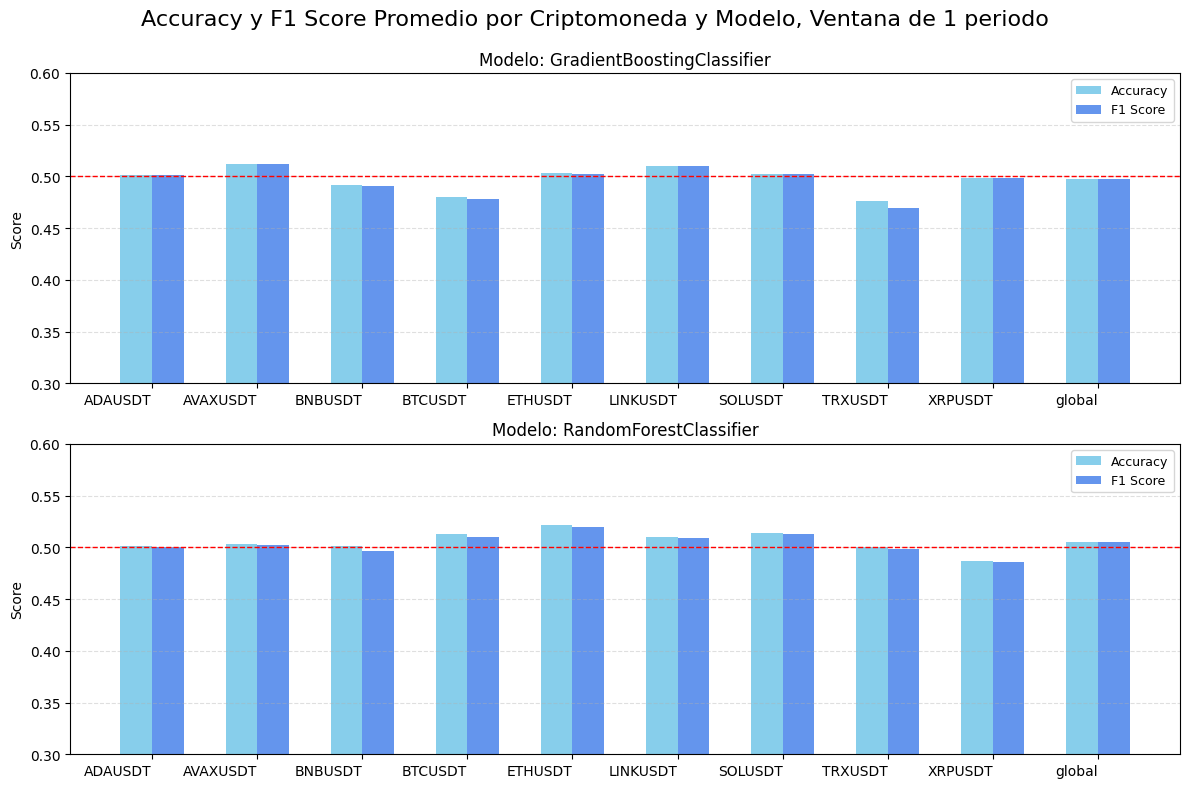

In [3]:
metrics_df = dataframes['final_results_globW1']
# Agrupar por modelo y criptomoneda: media de acc y f1
avg_per_crypto_model = pivot_df.groupby(["model", "crypto"])[["acc", "f1"]].mean().reset_index()

# Obtener lista de modelos únicos
models = avg_per_crypto_model["model"].unique()

# Crear subplots dinámicos (uno por modelo)
n_models = len(models)
fig, axs = plt.subplots(n_models, 1, figsize=(12, 4 * n_models), sharey=True)

if n_models == 1:
    axs = [axs]  # Por si solo hay un modelo

for idx, model in enumerate(models):
    ax = axs[idx]
    df_model = avg_per_crypto_model[avg_per_crypto_model["model"] == model]
    cryptos = df_model["crypto"].values
    acc = df_model["acc"].values
    f1 = df_model["f1"].values
    x = np.arange(len(cryptos))

    ax.bar(x - 0.15, acc, width=0.3, label="Accuracy", color="skyblue")
    ax.bar(x + 0.15, f1, width=0.3, label="F1 Score", color="cornflowerblue")
    ax.set_xticks(x)
    ax.set_xticklabels(cryptos, ha="right", fontsize=10)
    ax.set_title(f"Modelo: {model}", fontsize=12)
    ax.set_ylim(0.3, 0.6)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.axhline(y=0.5, color="red", linestyle="--", linewidth=1)
    ax.legend(fontsize=9)
    ax.set_ylabel("Score")

fig.suptitle("Accuracy y F1 Score Promedio por Criptomoneda y Modelo, Ventana de 1 periodo", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

W7

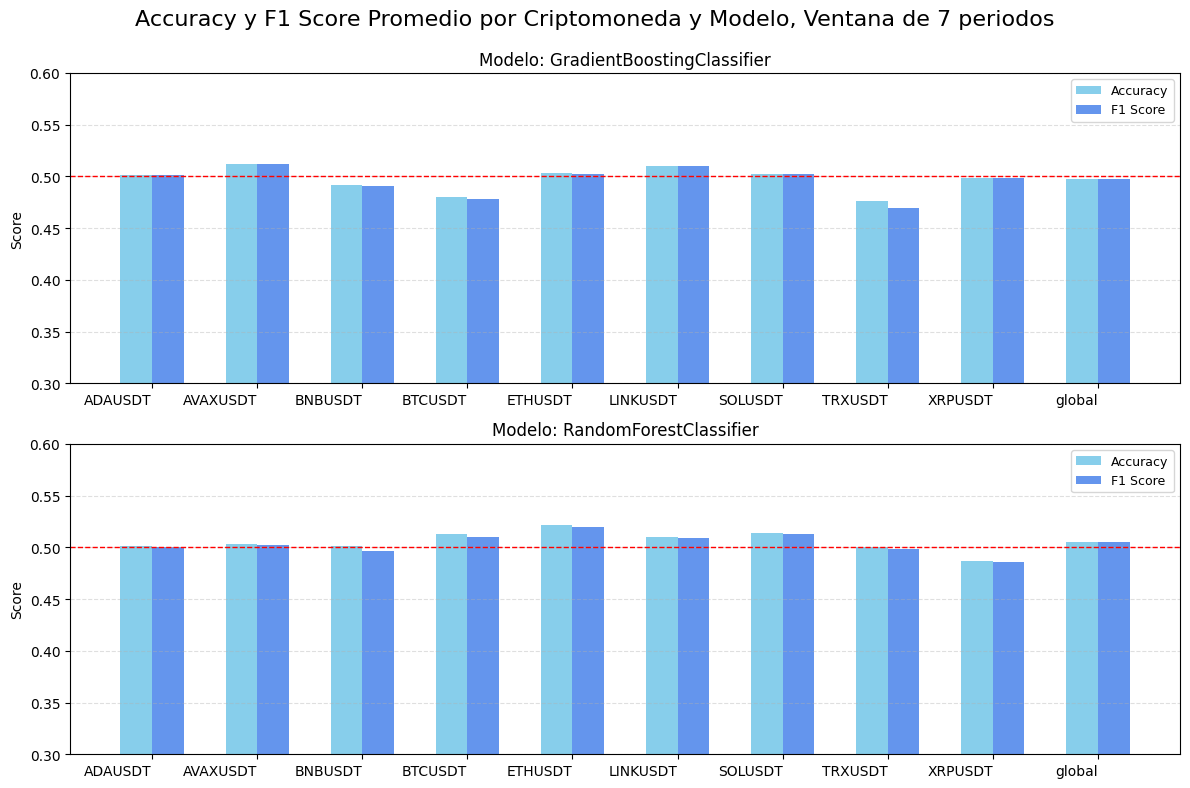

In [4]:
metrics_df = dataframes['final_results_globW7']

# Agrupar por modelo y criptomoneda: media de acc y f1
avg_per_crypto_model = pivot_df.groupby(["model", "crypto"])[["acc", "f1"]].mean().reset_index()

# Obtener lista de modelos únicos
models = avg_per_crypto_model["model"].unique()

# Crear subplots dinámicos (uno por modelo)
n_models = len(models)
fig, axs = plt.subplots(n_models, 1, figsize=(12, 4 * n_models), sharey=True)

if n_models == 1:
    axs = [axs]  # Por si solo hay un modelo

for idx, model in enumerate(models):
    ax = axs[idx]
    df_model = avg_per_crypto_model[avg_per_crypto_model["model"] == model]
    cryptos = df_model["crypto"].values
    acc = df_model["acc"].values
    f1 = df_model["f1"].values
    x = np.arange(len(cryptos))

    ax.bar(x - 0.15, acc, width=0.3, label="Accuracy", color="skyblue")
    ax.bar(x + 0.15, f1, width=0.3, label="F1 Score", color="cornflowerblue")
    ax.set_xticks(x)
    ax.set_xticklabels(cryptos, ha="right", fontsize=10)
    ax.set_title(f"Modelo: {model}", fontsize=12)
    ax.set_ylim(0.3, 0.6)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.axhline(y=0.5, color="red", linestyle="--", linewidth=1)
    ax.legend(fontsize=9)
    ax.set_ylabel("Score")

fig.suptitle("Accuracy y F1 Score Promedio por Criptomoneda y Modelo, Ventana de 7 periodos", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

Acc y F1 por modelo, cada barra es una criptomoneda

W1

C:\Users\raque\AppData\Local\Temp\ipykernel_8104\2784975537.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlGnBu_r')


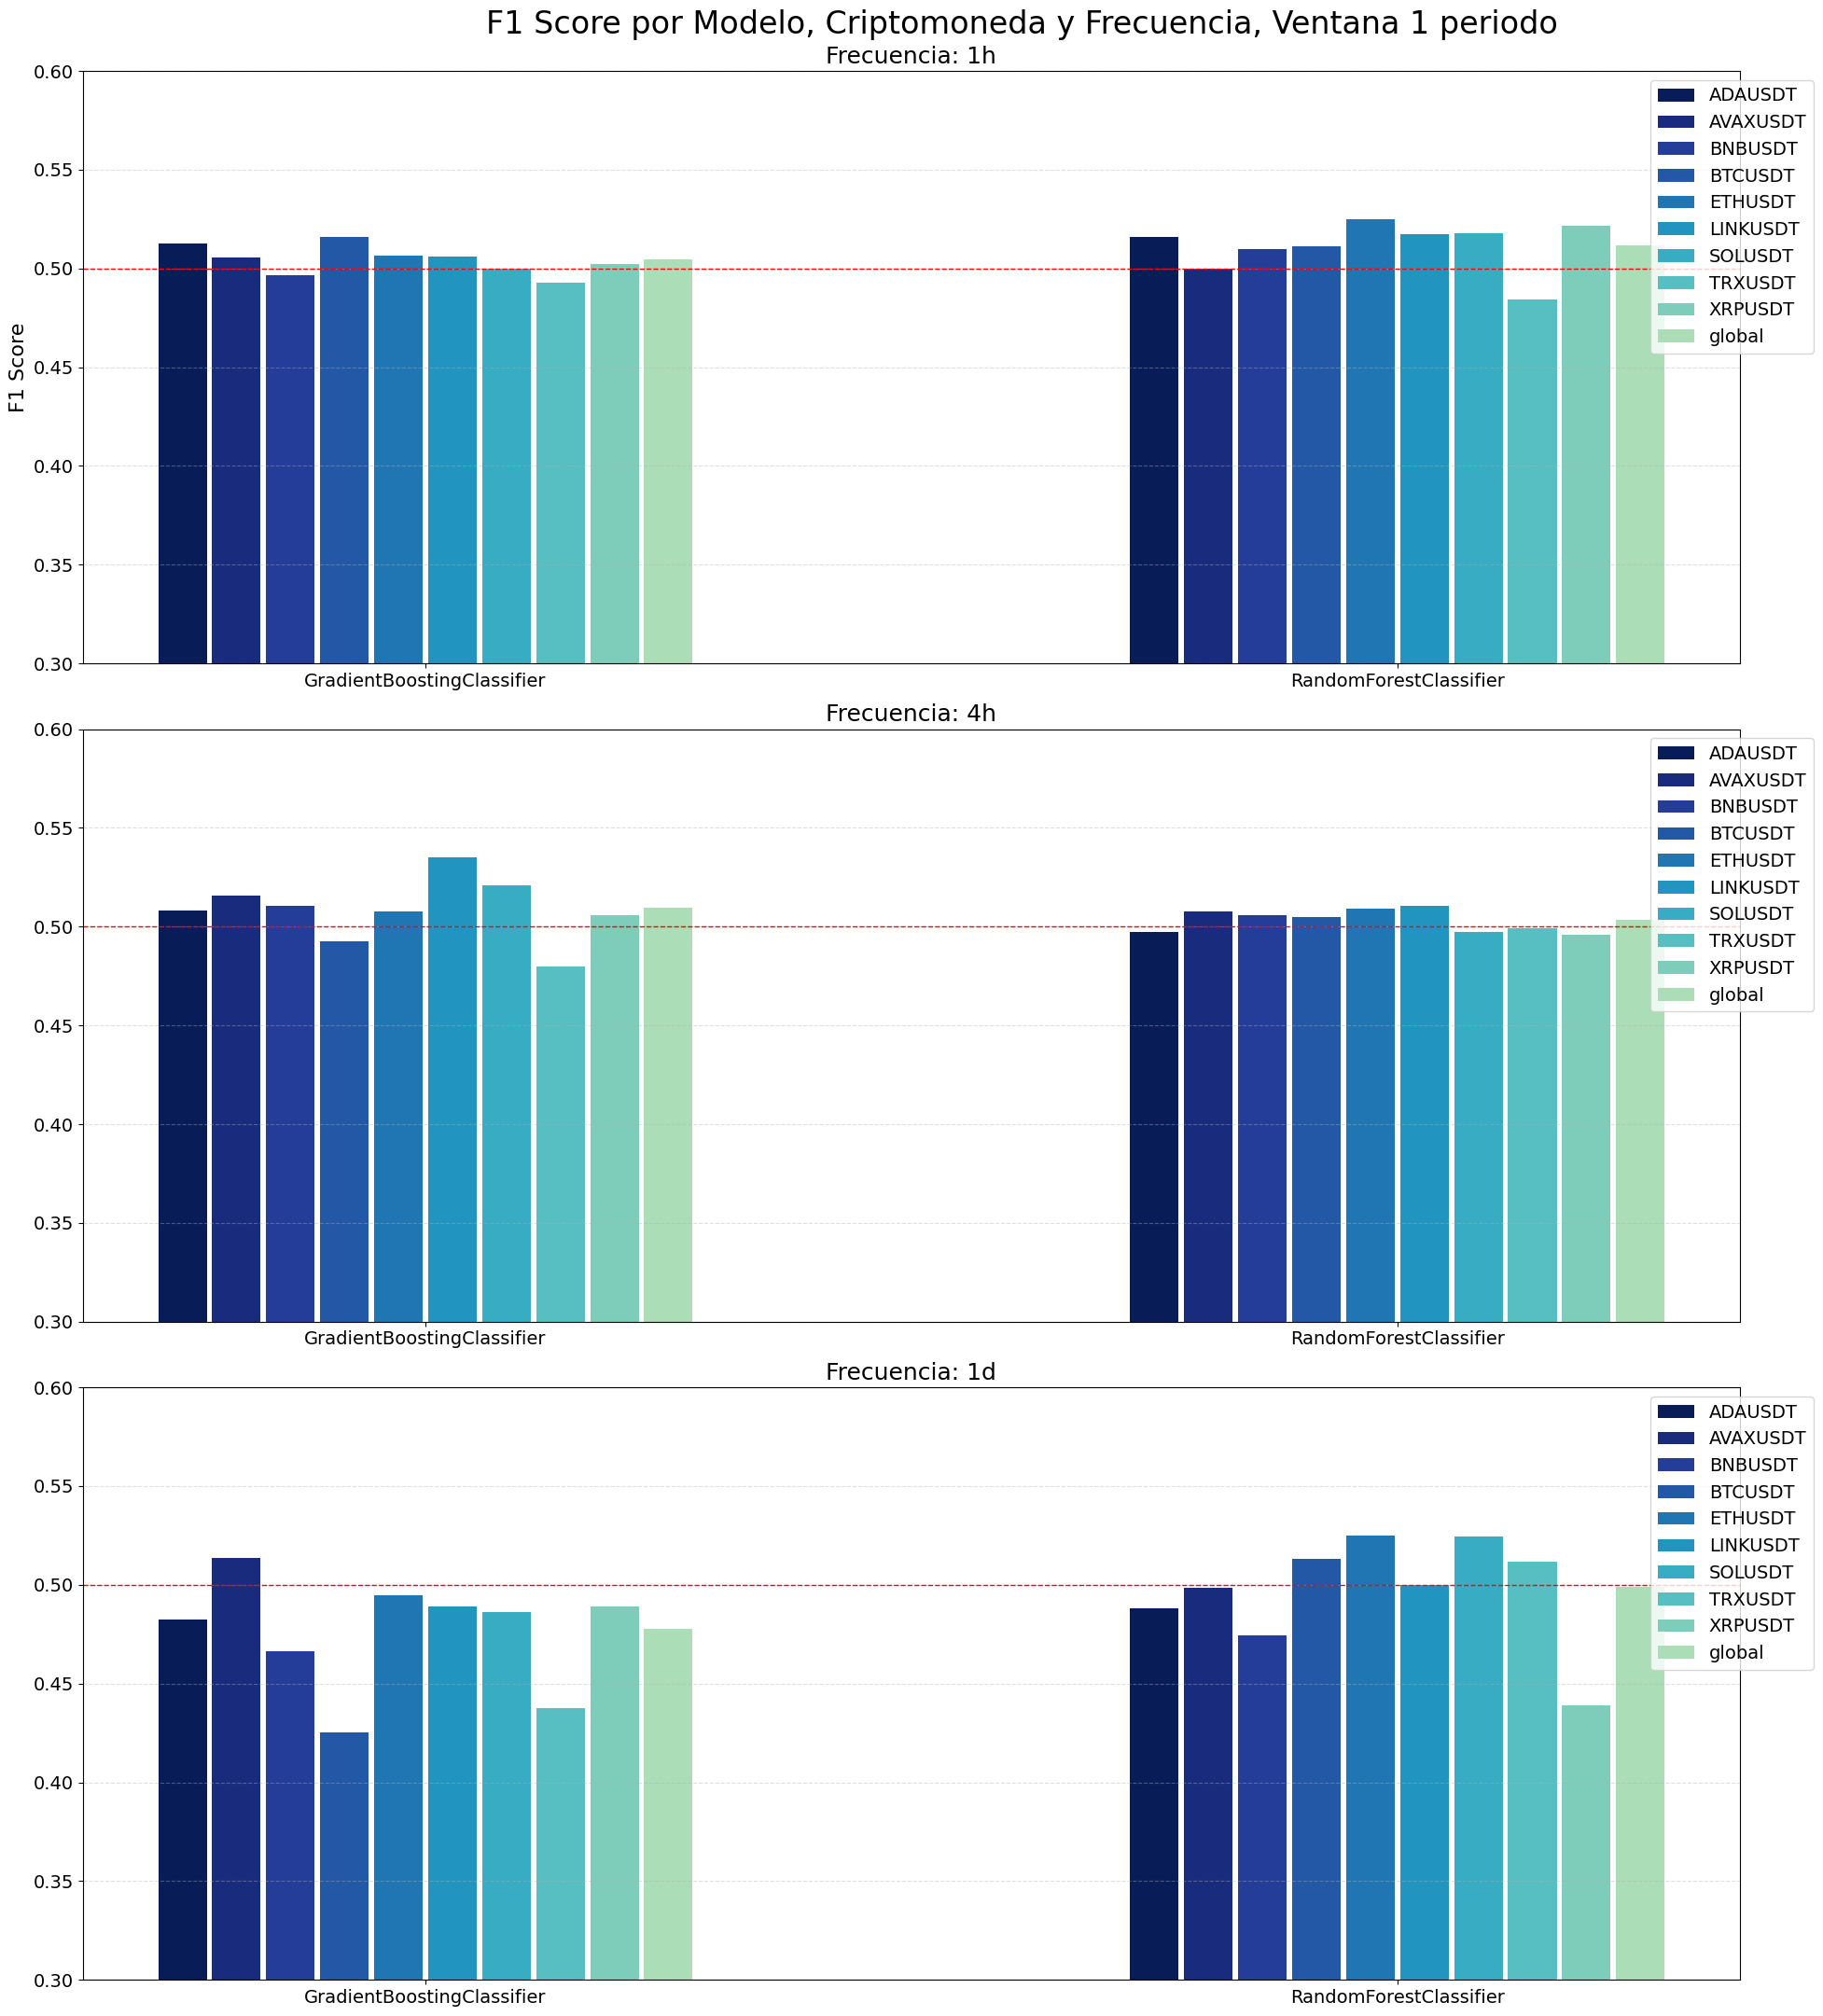

In [5]:
metrics_df = dataframes['final_results_globW1']
# Configuración
frequencies = ["1h", "4h", "1d"]
cryptos = pivot_df["crypto"].unique()
n = len(cryptos)
cmap = cm.get_cmap('YlGnBu_r')  
colors = [cmap(i / (n - 1) * 0.7) for i in range(n)]
bar_width = 0.05

fig, axs = plt.subplots(3, 1, figsize=(22, 22), sharey=True)

for idx, freq in enumerate(frequencies):
    ax = axs[idx]
    df_freq = pivot_df[pivot_df["frequency"] == freq]
    models = df_freq["model"].unique()
    x = np.arange(len(models))
    total_bars = len(cryptos)
    offsets = np.linspace(- bar_width * total_bars / 2, bar_width * total_bars / 2, total_bars)

    for i, crypto in enumerate(cryptos):
        color_base = colors[i]
        # Agrupamos por modelo y calculamos la media del f1 para esa cripto
        values = (
            df_freq[df_freq["crypto"] == crypto]
            .groupby("model")["f1"]
            .mean()
            .reindex(models)
        )
        label = crypto
        position = x + offsets[i]
        ax.bar(position, values, width=bar_width, label=label, color=color_base, alpha=1)

    ax.set_title(f"Frecuencia: {freq}", fontsize=18)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

axs[0].set_ylabel("F1 Score", fontsize=16)
axs[0].set_ylim(0.3, 0.6)

# Leyenda común
for ax in axs:
    ax.legend(loc="upper right", bbox_to_anchor=(1.05, 1), fontsize=14)

fig.suptitle("F1 Score por Modelo, Criptomoneda y Frecuencia, Ventana 1 periodo", fontsize=24)
plt.tight_layout()
plt.subplots_adjust(top=0.95, right=0.85)
plt.show()

W7

C:\Users\raque\AppData\Local\Temp\ipykernel_8104\4199961680.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlGnBu_r')


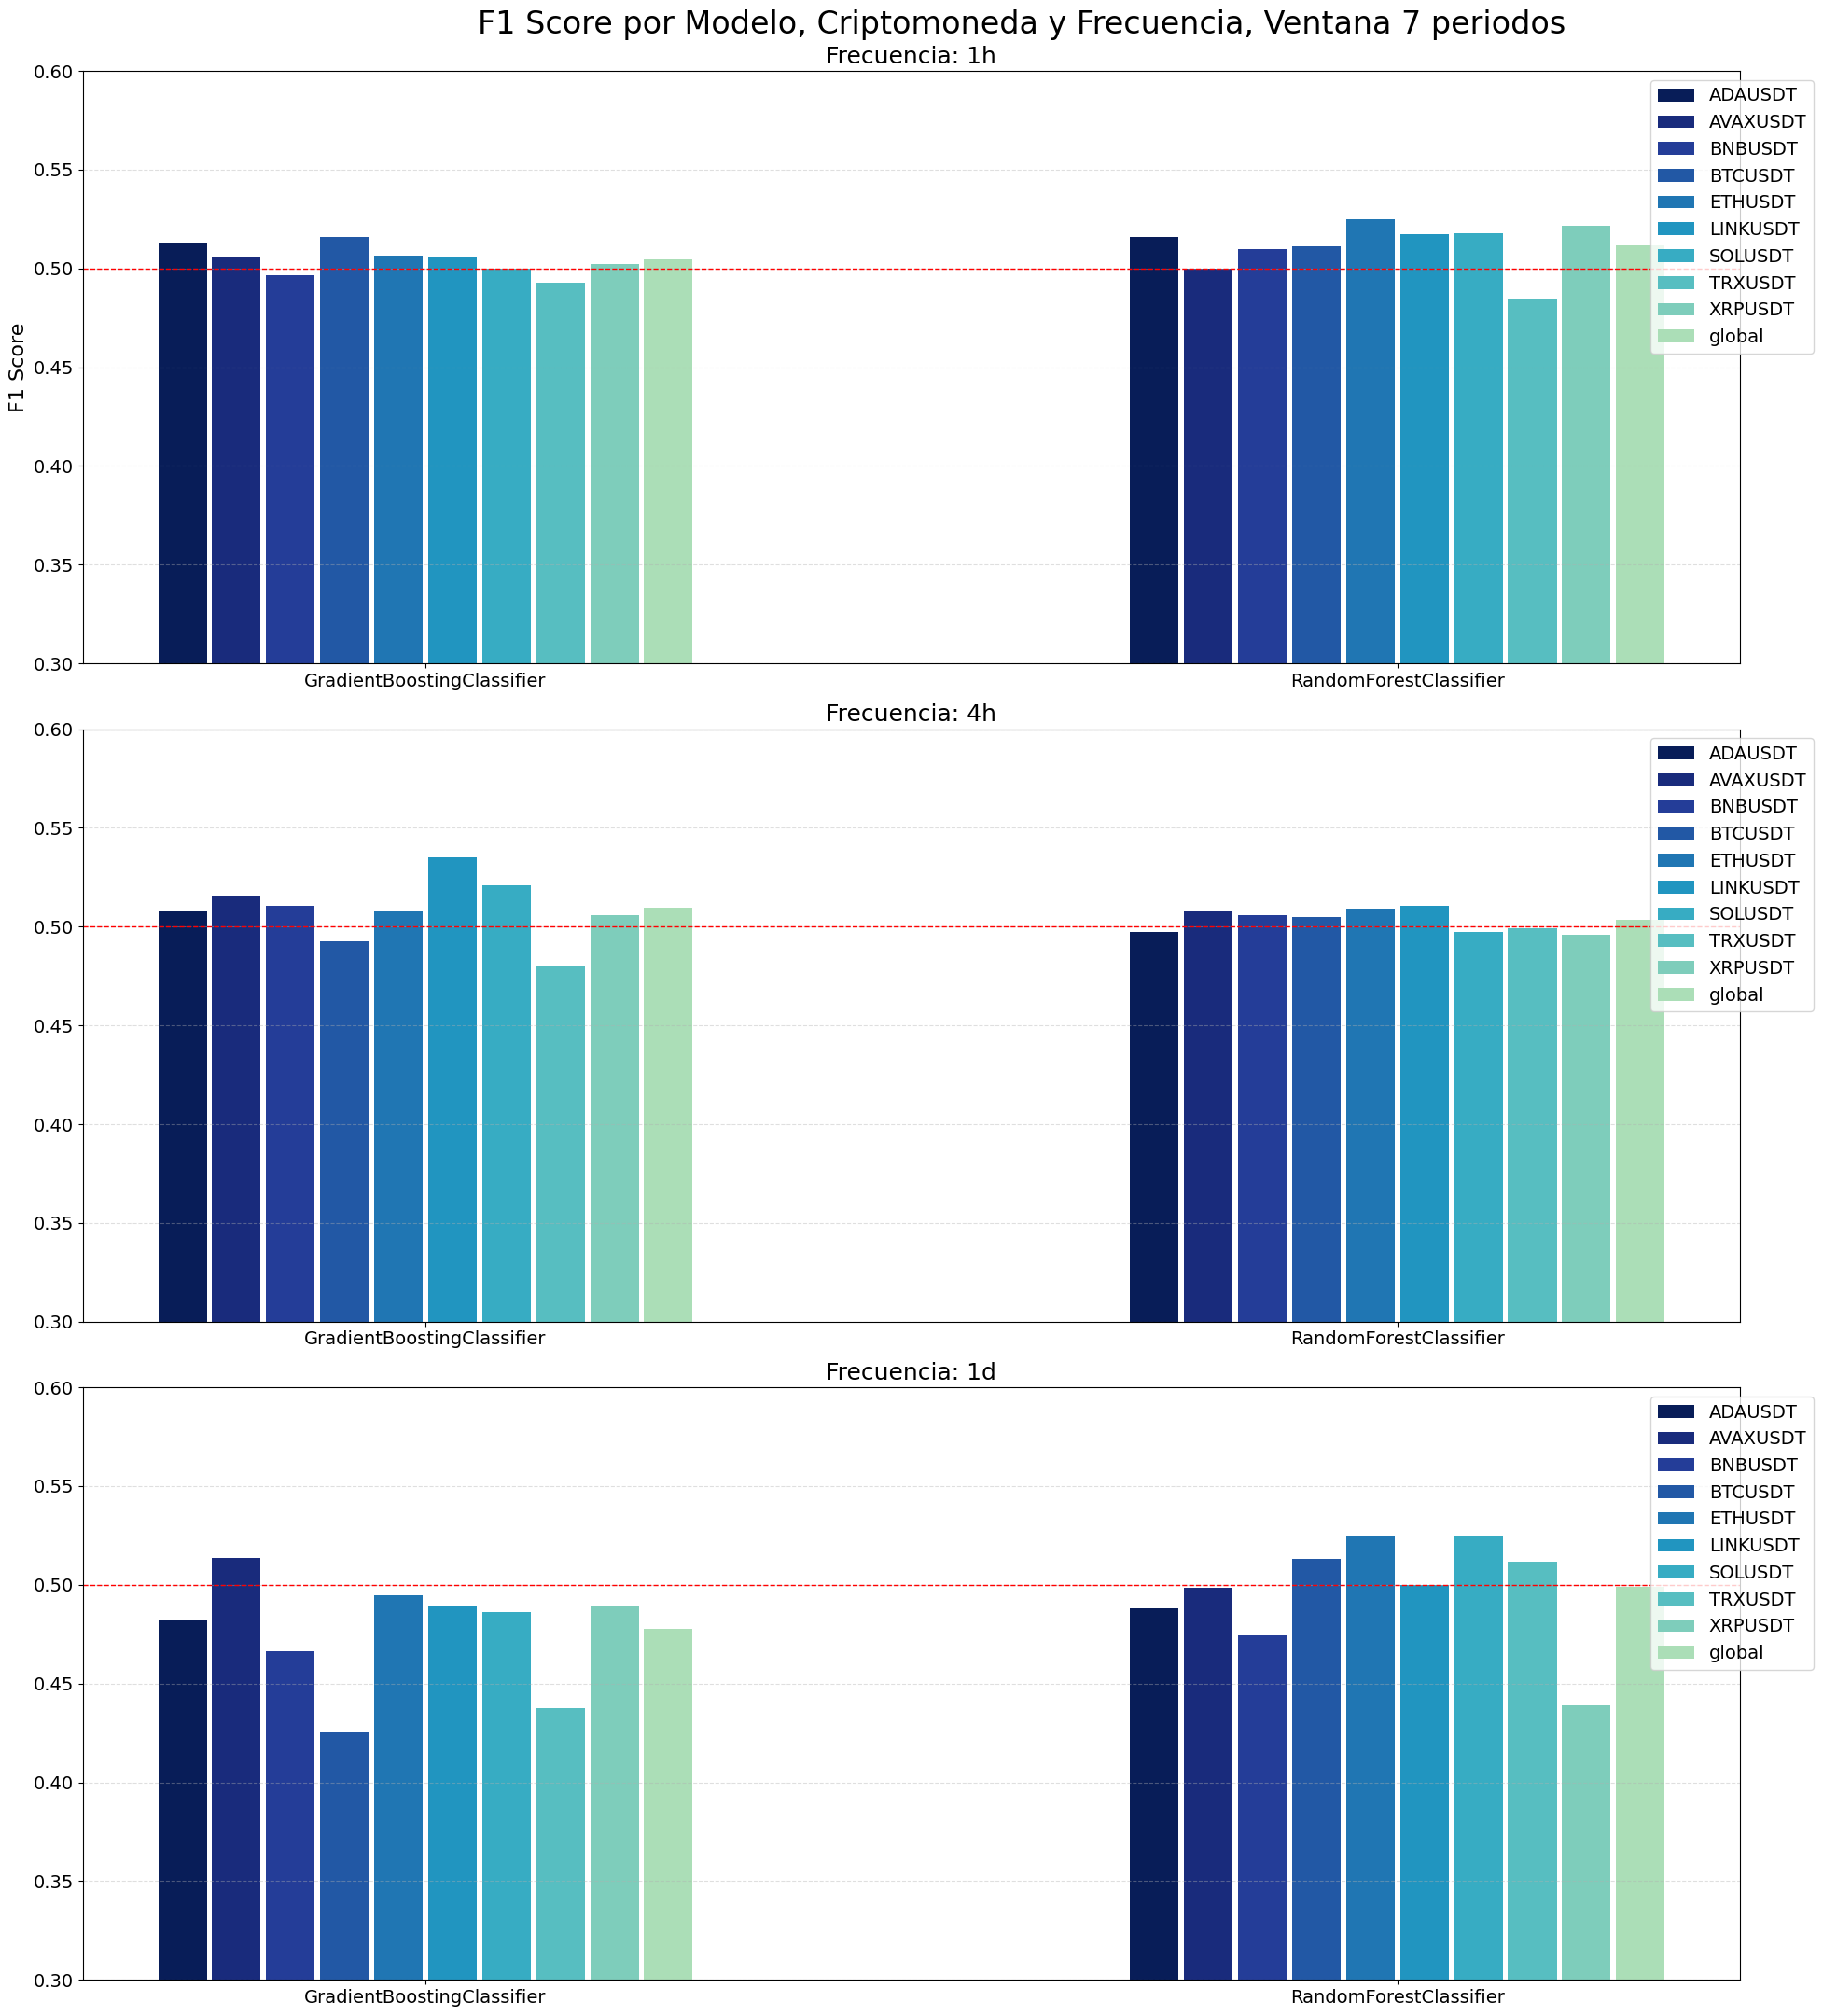

In [6]:
metrics_df = dataframes['final_results_globW7']
# Configuración
frequencies = ["1h", "4h", "1d"]
cryptos = pivot_df["crypto"].unique()
n = len(cryptos)
cmap = cm.get_cmap('YlGnBu_r')  
colors = [cmap(i / (n - 1) * 0.7) for i in range(n)]
bar_width = 0.05

fig, axs = plt.subplots(3, 1, figsize=(22, 22), sharey=True)

for idx, freq in enumerate(frequencies):
    ax = axs[idx]
    df_freq = pivot_df[pivot_df["frequency"] == freq]
    models = df_freq["model"].unique()
    x = np.arange(len(models))
    total_bars = len(cryptos)
    offsets = np.linspace(- bar_width * total_bars / 2, bar_width * total_bars / 2, total_bars)

    for i, crypto in enumerate(cryptos):
        color_base = colors[i]
        # Agrupamos por modelo y calculamos la media del f1 para esa cripto
        values = (
            df_freq[df_freq["crypto"] == crypto]
            .groupby("model")["f1"]
            .mean()
            .reindex(models)
        )
        label = crypto
        position = x + offsets[i]
        ax.bar(position, values, width=bar_width, label=label, color=color_base, alpha=1)

    ax.set_title(f"Frecuencia: {freq}", fontsize=18)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

axs[0].set_ylabel("F1 Score", fontsize=16)
axs[0].set_ylim(0.3, 0.6)

# Leyenda común
for ax in axs:
    ax.legend(loc="upper right", bbox_to_anchor=(1.05, 1), fontsize=14)

fig.suptitle("F1 Score por Modelo, Criptomoneda y Frecuencia, Ventana 7 periodos", fontsize=24)
plt.tight_layout()
plt.subplots_adjust(top=0.95, right=0.85)
plt.show()

Tabla comparación de ventanas por cripto

In [7]:
columna_f1 = "f1"  
frecuencias = set()
for df in dataframes.values():
    frecuencias.update(df["frequency"].unique())

for freq in frecuencias:
    tablas_resultado = []

    for nombre_dataset, df in dataframes.items():
        # Filtrar por modelo y frecuencia
        df_filtrado = df[
            (df["model"] == "RandomForestClassifier") &
            (df["frequency"] == freq)
        ]

        # Calcular media por criptomoneda
        resumen = df_filtrado.groupby("crypto")[columna_f1].mean().reset_index()
        resumen["ventana"] = nombre_dataset  # la ventana es el nombre del dataset

        tablas_resultado.append(resumen)

    # Unir todos los resultados
    df_comparativo = pd.concat(tablas_resultado)

    # Pivot: filas=cripto, columnas=ventana, valores=f1
    tabla_f1 = df_comparativo.pivot(index="crypto", columns="ventana", values=columna_f1)

    # Añadir fila de media
    tabla_f1.loc['Media'] = tabla_f1[~tabla_f1.index.isin(['global'])].mean()

    tabla_f1 = tabla_f1.round(4)

    # Mostrar
    print(f"\nF1-score medio por criptomoneda y ventana temporal - Frecuencia {freq}:")
    display(tabla_f1)


F1-score medio por criptomoneda y ventana temporal - Frecuencia 4h:


ventana,final_results_globW1,final_results_globW7
crypto,,
ADAUSDT,0.4975,0.4968
AVAXUSDT,0.5078,0.5402
BNBUSDT,0.5060,0.4823
BTCUSDT,0.5046,0.4950
ETHUSDT,0.5093,0.5004
LINKUSDT,0.5106,0.5031
SOLUSDT,0.4973,0.5110
TRXUSDT,0.4991,0.4548
XRPUSDT,0.4959,0.5167



F1-score medio por criptomoneda y ventana temporal - Frecuencia 1h:


ventana,final_results_globW1,final_results_globW7
crypto,,
ADAUSDT,0.5160,0.5064
AVAXUSDT,0.5000,0.4990
BNBUSDT,0.5098,0.5082
BTCUSDT,0.5112,0.5145
ETHUSDT,0.5250,0.5161
LINKUSDT,0.5173,0.4993
SOLUSDT,0.5179,0.5088
TRXUSDT,0.4844,0.4900
XRPUSDT,0.5215,0.5192



F1-score medio por criptomoneda y ventana temporal - Frecuencia 1d:


ventana,final_results_globW1,final_results_globW7
crypto,,
ADAUSDT,0.4882,0.4982
AVAXUSDT,0.4986,0.5131
BNBUSDT,0.4742,0.4781
BTCUSDT,0.5133,0.5514
ETHUSDT,0.5247,0.4973
LINKUSDT,0.5000,0.5030
SOLUSDT,0.5245,0.4394
TRXUSDT,0.5119,0.4946
XRPUSDT,0.4389,0.5360


In [8]:
columna_f1 = "f1"  # cambia esto si tiene otro nombre exacto

# Lista para almacenar resultados
tablas_resultado = []

for nombre_dataset, df in dataframes.items():
    # Filtrar por modelo
    df_filtrado = df[df['model'] == 'RandomForestClassifier']

    resumen = df_filtrado.groupby('crypto')[columna_f1].mean().reset_index()
    resumen['ventana'] = nombre_dataset  # la ventana es el nombre del dataset

    tablas_resultado.append(resumen)

# Combinar todos los resultados
df_comparativo = pd.concat(tablas_resultado)

# Pivot: filas=cripto, columnas=ventana, celdas=f1
tabla_f1 = df_comparativo.pivot(index='crypto', columns='ventana', values=columna_f1)

# Añadir fila de media
tabla_f1.loc['Media'] = tabla_f1[~tabla_f1.index.isin(['global'])].mean()


tabla_f1 = tabla_f1.round(4)
# Mostrar tabla
print(" F1-score medio por criptomoneda y ventana temporal (incluye media):")
display(tabla_f1)

 F1-score medio por criptomoneda y ventana temporal (incluye media):


ventana,final_results_globW1,final_results_globW7
crypto,,
ADAUSDT,0.5006,0.5005
AVAXUSDT,0.5022,0.5174
BNBUSDT,0.4966,0.4895
BTCUSDT,0.5097,0.5203
ETHUSDT,0.5197,0.5046
LINKUSDT,0.5093,0.5018
SOLUSDT,0.5132,0.4864
TRXUSDT,0.4985,0.4798
XRPUSDT,0.4855,0.5240


Tabla comparación de ventanas por freq

In [9]:
columna_f1 = "f1"  # cambia esto si tiene otro nombre exacto

# Lista para almacenar resultados
tablas_resultado = []

for nombre_dataset, df in dataframes.items():
    # Filtrar por modelo
    df_filtrado = df[df['model'] == 'RandomForestClassifier']

    resumen = df_filtrado.groupby('frequency')[columna_f1].mean().reset_index()
    resumen['ventana'] = nombre_dataset  # la ventana es el nombre del dataset

    tablas_resultado.append(resumen)

# Combinar todos los resultados
df_comparativo = pd.concat(tablas_resultado)

# Pivot: filas=cripto, columnas=ventana, celdas=f1
tabla_f1 = df_comparativo.pivot(index='frequency', columns='ventana', values=columna_f1)

# Añadir fila de media
tabla_f1.loc['Media'] = tabla_f1[~tabla_f1.index.isin(['global'])].mean()

tabla_f1 = tabla_f1.round(4)
# Mostrar tabla
print(" F1-score medio por criptomoneda y ventana temporal (incluye media):")
display(tabla_f1)

 F1-score medio por criptomoneda y ventana temporal (incluye media):


ventana,final_results_globW1,final_results_globW7
frequency,,
1d,0.4974,0.5031
1h,0.5115,0.5068
4h,0.5032,0.5006
Media,0.5040,0.5035


In [10]:
tablas_por_modelo = {}

for nombre_dataset, df in dataframes.items():
    if not all(col in df.columns for col in ['model', 'crypto', 'f1']):
        print(f" El dataset '{nombre_dataset}' no contiene las columnas necesarias ('model', 'crypto', 'f1')")
        continue

    # Agrupar por modelo y cripto, calcular media del f1
    tabla = df.groupby(['crypto', 'model'])['f1'].mean().unstack()

    tabla.loc['Media'] = tabla[~tabla.index.isin(['global'])].mean()
    tabla = tabla.round(4)

    print(f"\n F1-score medio por modelo y criptomoneda - {nombre_dataset}")
    display(tabla)

    tablas_por_modelo[nombre_dataset] = tabla



 F1-score medio por modelo y criptomoneda - final_results_globW7


model,GradientBoostingClassifier,RandomForestClassifier
crypto,,
ADAUSDT,0.4978,0.5005
AVAXUSDT,0.5033,0.5174
BNBUSDT,0.4901,0.4895
BTCUSDT,0.5254,0.5203
ETHUSDT,0.5058,0.5046
LINKUSDT,0.4943,0.5018
SOLUSDT,0.4993,0.4864
TRXUSDT,0.4851,0.4798
XRPUSDT,0.5075,0.5240



 F1-score medio por modelo y criptomoneda - final_results_globW1


model,GradientBoostingClassifier,RandomForestClassifier
crypto,,
ADAUSDT,0.5011,0.5006
AVAXUSDT,0.5116,0.5022
BNBUSDT,0.4912,0.4966
BTCUSDT,0.4779,0.5097
ETHUSDT,0.5029,0.5197
LINKUSDT,0.5100,0.5093
SOLUSDT,0.5023,0.5132
TRXUSDT,0.4700,0.4985
XRPUSDT,0.4989,0.4855


Comparación de modelo experto y global

datos expertos

In [11]:
filepaths = [
    "./EXPERTO W7/final_results_characW7.csv",
    "./EXPERTO W1/final_results_characW1.csv"
]

dataframes_exp = {}

for filepath in filepaths:
    dataset_name = filepath.split('/')[-1].replace('.csv', '')
    df = pd.read_csv(filepath)
    print(f"Procesando archivo: {dataset_name}")
    
    # Separar métricas
    acc_df = df[df["What"] == "FINAL TEST"].copy()
    acc_df["acc"] = pd.to_numeric(acc_df["Value"], errors="coerce")
    
    f1_df = df[df["What"] == "F1 FINAL TEST"].copy()
    f1_df["f1"] = pd.to_numeric(f1_df["Value"], errors="coerce")
    
    # Seleccionar columnas clave
    acc_df = acc_df[["Frequency", "Asset", "Model", "acc"]]
    f1_df = f1_df[["Frequency", "Asset", "Model", "f1"]]
    
    # Unir por clave
    metrics_df = pd.merge(acc_df, f1_df, on=["Frequency", "Asset", "Model"], how="outer")
    
    # Renombrar
    metrics_df = metrics_df.rename(columns={
        "Frequency": "frequency",
        "Asset": "crypto",
        "Model": "model"
    })
    
    # Limpiar nombre de criptomonedas
    metrics_df["crypto"] = metrics_df["crypto"].apply(lambda x: re.sub(r'_\d+[hd]', '', x))
    
    dataframes_exp[dataset_name] = metrics_df
    

Procesando archivo: final_results_characW7
Procesando archivo: final_results_characW1


In [12]:
# Selecciona los dataframes de la ventana a comparar
dataframes = {
    'final_results_globW1': dataframes['final_results_globW1'],
    'final_results_characW1': dataframes_exp['final_results_characW1'],
    'final_results_globW7': dataframes['final_results_globW7'],
    'final_results_characW7': dataframes_exp['final_results_characW7']
}

# Lista para almacenar resultados
tablas_resultado = []

for nombre_dataset, df in dataframes.items():
    # Filtrar por modelo
    df_filtrado = df[df['model'] == 'RandomForestClassifier']

    resumen = df_filtrado.groupby('crypto')["f1"].mean().reset_index()
    resumen['ventana'] = nombre_dataset  # la ventana es el nombre del dataset

    tablas_resultado.append(resumen)

# Combinar todos los resultados
df_comparativo = pd.concat(tablas_resultado)

# Pivot: filas=cripto, columnas=ventana, celdas=f1
tabla_f1 = df_comparativo.pivot(index='crypto', columns='ventana', values="f1")

# Añadir fila de media y número de criptos por encima de 0.5
tabla_f1.loc['>0.5'] = (tabla_f1[tabla_f1.index != 'global'] > 0.5).sum()
tabla_f1.loc['Media'] = tabla_f1[~tabla_f1.index.isin(['global', '>0.5'])].mean()

tabla_f1 = tabla_f1.round(4)
# Mostrar tabla
print(" F1-score medio por criptomoneda y ventana temporal (incluye media):")
display(tabla_f1)

 F1-score medio por criptomoneda y ventana temporal (incluye media):


ventana,final_results_characW1,final_results_characW7,final_results_globW1,final_results_globW7
crypto,,,,
ADAUSDT,0.4975,0.4952,0.5006,0.5005
AVAXUSDT,0.5048,0.5369,0.5022,0.5174
BNBUSDT,0.4958,0.4875,0.4966,0.4895
BTCUSDT,0.5081,0.5004,0.5097,0.5203
ETHUSDT,0.5025,0.4982,0.5197,0.5046
LINKUSDT,0.5130,0.4904,0.5093,0.5018
SOLUSDT,0.5077,0.4973,0.5132,0.4864
TRXUSDT,0.4871,0.4780,0.4985,0.4798
XRPUSDT,0.5088,0.5034,0.4855,0.5240
